# SupplyGraph Data Exploration

## 0) Setup

Goal: set imports, display options, and file paths.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from IPython.display import display


/home/elesquina/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Core paths and notebook behavior
data_root_candidates = [
    Path("RawData"),
    Path("DataExploration") / "RawData",
]
ROOT = next((p for p in data_root_candidates if p.exists()), None)
if ROOT is None:
    searched = ", ".join(str(p) for p in data_root_candidates)
    raise FileNotFoundError(f"Could not find dataset root. Checked: {searched}")

NODES_DIR = ROOT / "Nodes"
EDGES_DIR = ROOT / "Edges"
EDGES_INDEX_DIR = EDGES_DIR / "EdgesIndex"
UNIT_DIR = ROOT / "Temporal Data" / "Unit"
WEIGHT_DIR = ROOT / "Temporal Data" / "Weight"

PROCESSED_DIR = ROOT.parent / "Processed"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


## 1) File Inventory

Goal: understand what files exist and their rough size.

1. List all CSVs under `SupplyGraph/`.
2. Build a summary table with: file path, rows, columns.
3. Add a short note: which files are nodes, edges, and temporal metrics.

In [3]:
# Inventory of all CSV files and basic shapes
csv_files = sorted(ROOT.rglob("*.csv"))

inventory_records = []
for path in csv_files:
    df = pd.read_csv(path)
    rel = path.relative_to(ROOT)

    if rel.parts[0] == "Nodes":
        family = "nodes"
    elif rel.parts[0] == "Edges":
        family = "edges"
    elif rel.parts[0] == "Temporal Data":
        family = f"temporal_{rel.parts[1].lower()}"
    else:
        family = "other"

    inventory_records.append(
        {
            "file": str(rel),
            "family": family,
            "rows": len(df),
            "cols": df.shape[1],
        }
    )

inventory_df = pd.DataFrame(inventory_records)
if set(["family", "file"]).issubset(inventory_df.columns):
    inventory_df = inventory_df.sort_values(["family", "file"]).reset_index(drop=True)
else:
    inventory_df = pd.DataFrame(columns=["file", "family", "rows", "cols"])

if inventory_df.empty:
    print(f"No CSV files found under ROOT={ROOT}")
else:
    display(inventory_df)
    print("\nFile counts by family:")
    display(inventory_df.groupby("family")["file"].count().rename("n_files").to_frame())


,file,family,rows,cols
0,Edges/Edges (Plant).csv,edges,1647,3
1,Edges/Edges (Product Group).csv,edges,188,3
2,Edges/Edges (Product Sub-Group).csv,edges,52,3
3,Edges/Edges (Storage Location).csv,edges,3046,3
4,Nodes/Node Types (Product Group and Subgroup).csv,nodes,41,3
5,Nodes/Nodes Type (Plant & Storage).csv,nodes,6545,3
6,Nodes/Nodes.csv,nodes,41,1
7,Temporal Data/Unit/Delivery To distributor.csv,temporal_unit,221,42
8,Temporal Data/Unit/Factory Issue.csv,temporal_unit,221,42
9,Temporal Data/Unit/Production .csv,temporal_unit,221,42



File counts by family:


,n_files
family,
edges,4
nodes,3
temporal_unit,4
temporal_weight,4


## 2) Raw Data Load

Goal: load each dataset into a DataFrame dictionary.

1. Load node files into `nodes_dfs`.
2. Load edge files into `edge_dfs`.
3. Load temporal Unit files into `unit_dfs`.
4. Load temporal Weight files into `weight_dfs`.
5. Display one sample (`head`) from each group.

In [4]:
def normalize_name(name: str) -> str:
    return re.sub(r"\s+", " ", name.strip().lower())


def infer_metric(filename: str) -> str:
    n = normalize_name(filename)
    if "sales order" in n:
        return "sales_order"
    if "factory issue" in n:
        return "factory_issue"
    if "production" in n:
        return "production"
    if "delivery" in n:
        return "delivery"
    return re.sub(r"[^a-z0-9]+", "_", n).strip("_")


# Load nodes
nodes_dfs = {f.stem: pd.read_csv(f) for f in sorted(NODES_DIR.glob("*.csv"))}

# Load edges (labels)
edge_dfs = {f.stem: pd.read_csv(f) for f in sorted(EDGES_DIR.glob("*.csv"))}

# Load edges (index version) only if the folder exists
edge_index_dfs = {}
if EDGES_INDEX_DIR.exists():
    edge_index_dfs = {f.stem: pd.read_csv(f) for f in sorted(EDGES_INDEX_DIR.glob("*.csv"))}

# Load temporal tables
unit_dfs = {f.stem: pd.read_csv(f) for f in sorted(UNIT_DIR.glob("*.csv"))}
weight_dfs = {f.stem: pd.read_csv(f) for f in sorted(WEIGHT_DIR.glob("*.csv"))}

# Metric maps for later sections
unit_metric_map = {k: infer_metric(k) for k in unit_dfs.keys()}
weight_metric_map = {k: infer_metric(k) for k in weight_dfs.keys()}


## 3) Data Quality Checks

Goal: identify duplicates, missing values, type issues, and naming inconsistencies.

1. For each DataFrame, compute:
   - row count
   - duplicate rows
   - missing values by column
2. Check if temporal date columns parse correctly.
3. Confirm no negative values in temporal numeric columns (or note exceptions).
4. Check column name consistency across temporal files (example: `.1` suffix problems).
5. Write a short cleaning plan below this section.

Important for this dataset:
- In several tables, repeated rows can encode occurrence frequency/edge strength.


In [5]:
# 1) Generic quality audit across all loaded DataFrames
all_groups = {
    **{f"nodes::{k}": v for k, v in nodes_dfs.items()},
    **{f"edges::{k}": v for k, v in edge_dfs.items()},
    **{f"edges_index::{k}": v for k, v in edge_index_dfs.items()},
    **{f"temporal_unit::{k}": v for k, v in unit_dfs.items()},
    **{f"temporal_weight::{k}": v for k, v in weight_dfs.items()},
}

quality_records = []
for name, df in all_groups.items():
    quality_records.append(
        {
            "dataset": name,
            "rows": len(df),
            "cols": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_cells": int(df.isna().sum().sum()),
            "cols_with_missing": int((df.isna().sum() > 0).sum()),
        }
    )

quality_df = pd.DataFrame(quality_records)
if not quality_df.empty:
    quality_df = quality_df.sort_values("dataset").reset_index(drop=True)
display(quality_df)

# 2) Date parse quality in temporal files
date_quality = []
for group_name, dfs in [("unit", unit_dfs), ("weight", weight_dfs)]:
    for name, df in dfs.items():
        if "Date" not in df.columns:
            continue
        parsed = pd.to_datetime(df["Date"], errors="coerce")
        date_quality.append(
            {
                "group": group_name,
                "file": name,
                "rows": len(df),
                "invalid_dates": int(parsed.isna().sum()),
                "min_date": parsed.min(),
                "max_date": parsed.max(),
            }
        )

date_quality_df = pd.DataFrame(date_quality)
if not date_quality_df.empty:
    date_quality_df = date_quality_df.sort_values(["group", "file"]).reset_index(drop=True)
display(date_quality_df)

# 3) Negative value checks in temporal numeric columns
negative_records = []
for group_name, dfs in [("unit", unit_dfs), ("weight", weight_dfs)]:
    for name, df in dfs.items():
        cols = [c for c in df.columns if c != "Date"]
        numeric = df[cols].apply(pd.to_numeric, errors="coerce") if cols else pd.DataFrame(index=df.index)
        negative_cells = int((numeric < 0).sum().sum()) if not numeric.empty else 0
        negative_records.append({"group": group_name, "file": name, "negative_cells": negative_cells})

negative_df = pd.DataFrame(negative_records)
if not negative_df.empty:
    negative_df = negative_df.sort_values(["group", "file"]).reset_index(drop=True)
display(negative_df)

# 4) Column naming consistency checks (.1 suffix patterns)
def canonical_product(col: str) -> str:
    return re.sub(r"\.\d+$", "", col)

column_consistency_records = []
for group_name, dfs in [("unit", unit_dfs), ("weight", weight_dfs)]:
    for name, df in dfs.items():
        cols = [c for c in df.columns if c != "Date"]
        canonical = [canonical_product(c) for c in cols]
        duplicates_after_canonical = len(canonical) - len(set(canonical))
        suffix_count = sum(c != canonical_product(c) for c in cols)
        column_consistency_records.append(
            {
                "group": group_name,
                "file": name,
                "n_product_columns": len(cols),
                "suffix_columns": suffix_count,
                "duplicates_after_canonical": duplicates_after_canonical,
            }
        )

column_consistency_df = pd.DataFrame(column_consistency_records)
if not column_consistency_df.empty:
    column_consistency_df = column_consistency_df.sort_values(["group", "file"]).reset_index(drop=True)
display(column_consistency_df)


,dataset,rows,cols,duplicate_rows,missing_cells,cols_with_missing
0,edges::Edges (Plant),1647,3,0,0,0
1,edges::Edges (Product Group),188,3,6,0,0
2,edges::Edges (Product Sub-Group),52,3,1,0,0
3,edges::Edges (Storage Location),3046,3,0,0,0
4,nodes::Node Types (Product Group and Subgroup),41,3,1,0,0
5,nodes::Nodes,41,1,1,0,0
6,nodes::Nodes Type (Plant & Storage),6545,3,6268,1,1
7,temporal_unit::Delivery To distributor,221,42,0,0,0
8,temporal_unit::Factory Issue,221,42,0,0,0
9,temporal_unit::Production,221,42,0,0,0


,group,file,rows,invalid_dates,min_date,max_date
0,unit,Delivery To distributor,221,0,2023-01-01,2023-08-09
1,unit,Factory Issue,221,0,2023-01-01,2023-08-09
2,unit,Production,221,0,2023-01-01,2023-08-09
3,unit,Sales Order,221,0,2023-01-01,2023-08-09
4,weight,Delivery to Distributor,221,0,2023-01-01,2023-08-09
5,weight,Factory Issue,221,0,2023-01-01,2023-08-09
6,weight,Production,221,0,2023-01-01,2023-08-09
7,weight,Sales Order,221,0,2023-01-01,2023-08-09


,group,file,negative_cells
0,unit,Delivery To distributor,0
1,unit,Factory Issue,0
2,unit,Production,0
3,unit,Sales Order,0
4,weight,Delivery to Distributor,0
5,weight,Factory Issue,0
6,weight,Production,0
7,weight,Sales Order,0


,group,file,n_product_columns,suffix_columns,duplicates_after_canonical
0,unit,Delivery To distributor,41,1,1
1,unit,Factory Issue,41,1,1
2,unit,Production,41,1,1
3,unit,Sales Order,41,1,1
4,weight,Delivery to Distributor,41,1,1
5,weight,Factory Issue,41,1,1
6,weight,Production,41,1,1
7,weight,Sales Order,41,1,1


## 4) Node and Edge Exploration

Goal: understand graph structure at a basic level.

1. Count unique nodes from node master table.
2. Validate node references in each edge file (`node1/node2` in node list).
3. Compute per-edge-file metrics:
   - number of edges
   - number of unique nodes touched
   - duplicate edge pairs (undirected)
4. Plot degree distribution for at least one edge type.
5. Note any structural anomalies.

6. Compare `Edges/` vs `EdgesIndex/` versions (labels vs node indices) and choose one canonical representation.
7. If duplicate pairs exist, create both views: unweighted (deduped) and weighted (pair count).


,edge_file,n_edges,unique_nodes_touched,duplicate_undirected_pairs,missing_node_refs
0,Edges (Plant),1647,40,1287,0
1,Edges (Product Group),188,40,9,0
2,Edges (Product Sub-Group),52,30,4,0
3,Edges (Storage Location),3046,40,2381,0


No missing node references across edge files.
Skipping index-based comparison (NodesIndex/EdgesIndex not available).


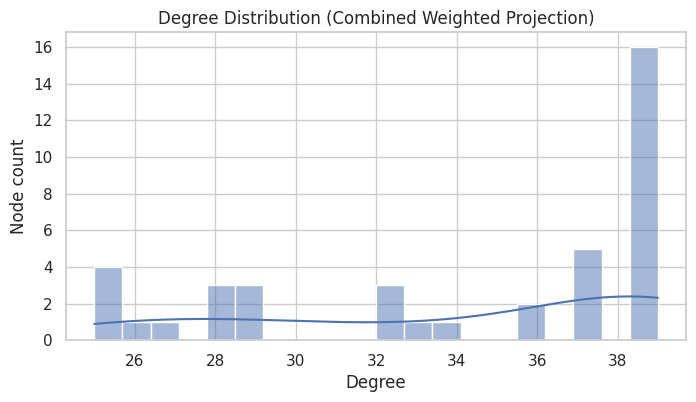

In [6]:
# Canonical node list
if "Nodes" in nodes_dfs and "Node" in nodes_dfs["Nodes"].columns:
    node_master = nodes_dfs["Nodes"][["Node"]].copy()
else:
    node_candidates = [df[["Node"]] for df in nodes_dfs.values() if "Node" in df.columns]
    if not node_candidates:
        raise ValueError("No node table with a 'Node' column was found in nodes_dfs.")
    node_master = node_candidates[0].copy()

node_set = set(node_master["Node"].astype(str))

# Build node attributes from all node tables
node_attrs = {n: {} for n in node_set}
for _, df in nodes_dfs.items():
    if "Node" not in df.columns:
        continue
    tmp = df.copy()
    tmp["Node"] = tmp["Node"].astype(str)
    for _, row in tmp.iterrows():
        n = row["Node"]
        if n not in node_attrs:
            node_attrs[n] = {}
        for col in tmp.columns:
            if col == "Node":
                continue
            val = row[col]
            if pd.notna(val):
                node_attrs[n][col] = val

edge_metrics = []
missing_ref_records = []
full_edge_rows = []

for edge_name, df in edge_dfs.items():
    if not {"node1", "node2"}.issubset(df.columns):
        continue

    temp = df.copy()
    temp["node1"] = temp["node1"].astype(str)
    temp["node2"] = temp["node2"].astype(str)

    pairs_undirected = temp[["node1", "node2"]].apply(lambda r: tuple(sorted((r["node1"], r["node2"]))), axis=1)
    duplicate_pairs = int(pairs_undirected.duplicated().sum())
    touched = set(temp["node1"]) | set(temp["node2"])

    missing_nodes = sorted(n for n in touched if n not in node_set)
    for n in missing_nodes:
        missing_ref_records.append({"edge_file": edge_name, "missing_node": n})

    edge_metrics.append(
        {
            "edge_file": edge_name,
            "n_edges": len(temp),
            "unique_nodes_touched": len(touched),
            "duplicate_undirected_pairs": duplicate_pairs,
            "missing_node_refs": len(missing_nodes),
        }
    )

    relation_cols = [c for c in temp.columns if c not in {"node1", "node2"}]
    relation_field = relation_cols[0] if relation_cols else None

    for ridx, row in temp.iterrows():
        full_edge_rows.append(
            {
                "source": str(row["node1"]),
                "target": str(row["node2"]),
                "edge_type": edge_name,
                "relation_field": relation_field,
                "relation_value": row[relation_field] if relation_field else None,
                "row_id": int(ridx),
            }
        )

edge_audit_df = pd.DataFrame(edge_metrics).sort_values("edge_file").reset_index(drop=True)
missing_refs_df = pd.DataFrame(missing_ref_records)
combined_edges_full = pd.DataFrame(full_edge_rows)

display(edge_audit_df)
if not missing_refs_df.empty:
    print("Missing node references found:")
    display(missing_refs_df.head(20))
else:
    print("No missing node references across edge files.")

# Optional: compare Edges (labels) vs EdgesIndex if both exist
if edge_index_dfs and ("NodesIndex" in nodes_dfs) and {"Node", "NodeIndex"}.issubset(nodes_dfs["NodesIndex"].columns):
    index_compare_records = []
    node_index_df = nodes_dfs["NodesIndex"].copy()
    valid_indices = set(pd.to_numeric(node_index_df["NodeIndex"], errors="coerce").dropna().astype(int))

    for name, df in edge_index_dfs.items():
        if not {"node1", "node2"}.issubset(df.columns):
            continue
        n1 = pd.to_numeric(df["node1"], errors="coerce")
        n2 = pd.to_numeric(df["node2"], errors="coerce")
        bad_index_rows = int((~n1.isin(valid_indices) | ~n2.isin(valid_indices)).sum())

        index_compare_records.append(
            {
                "edge_index_file": name,
                "rows": len(df),
                "bad_index_rows": bad_index_rows,
            }
        )

    index_compare_df = pd.DataFrame(index_compare_records).sort_values("edge_index_file").reset_index(drop=True)
    display(index_compare_df)
else:
    print("Skipping index-based comparison (NodesIndex/EdgesIndex not available).")

# Build full multi-edge graph (preserves duplicates and edge types)
G_full = nx.MultiGraph(name="SupplyGraph_Full")
for n, attrs in node_attrs.items():
    G_full.add_node(n, **attrs)

for r in full_edge_rows:
    G_full.add_edge(
        r["source"],
        r["target"],
        edge_type=r["edge_type"],
        relation_field=r["relation_field"],
        relation_value=r["relation_value"],
        row_id=r["row_id"],
    )

# Weighted undirected projection (pair count)
pair_weights = (
    combined_edges_full.assign(
        pair=combined_edges_full.apply(lambda x: tuple(sorted((x["source"], x["target"]))), axis=1)
    )
    .groupby("pair")
    .size()
    .reset_index(name="weight")
)

G_weighted = nx.Graph(name="SupplyGraph_Weighted")
for _, row in pair_weights.iterrows():
    u, v = row["pair"]
    G_weighted.add_edge(u, v, weight=int(row["weight"]))

# Degree distribution plot (unweighted degree on weighted projection)
degree_series = pd.Series(dict(G_weighted.degree()), name="degree")

plt.figure(figsize=(8, 4))
sns.histplot(degree_series, bins=20, kde=True)
plt.title("Degree Distribution (Combined Weighted Projection)")
plt.xlabel("Degree")
plt.ylabel("Node count")
plt.show()


## 5) Temporal Exploration (Wide Format)

Goal: get first insights before reshaping.

1. For each temporal file, parse `Date` and sort by date.
2. Compute daily total across all products.
3. Plot daily totals for Unit metrics and Weight metrics.
4. Compute zero-rate (sparsity) per file.
5. Identify top 10 products by total volume for each metric.

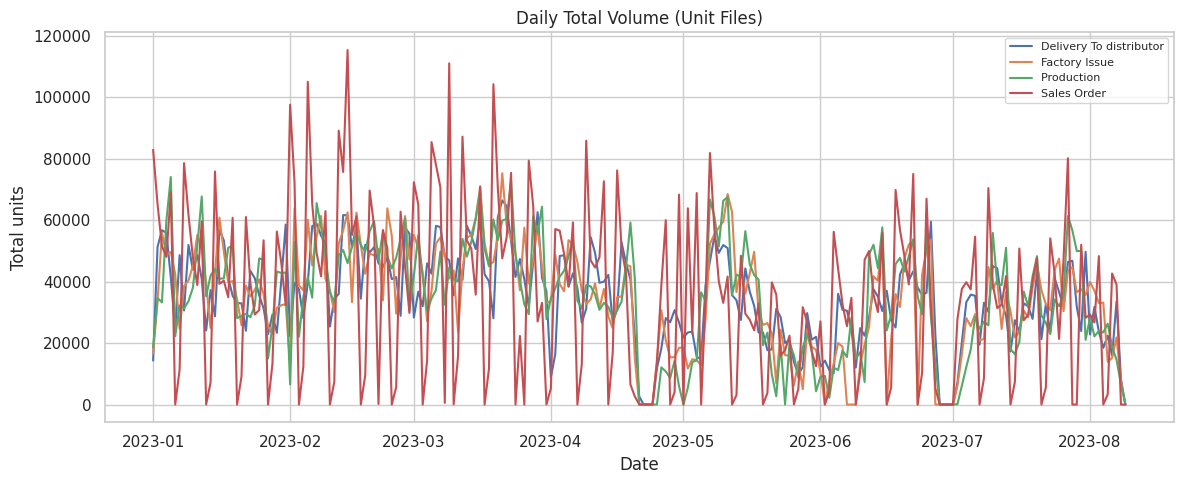

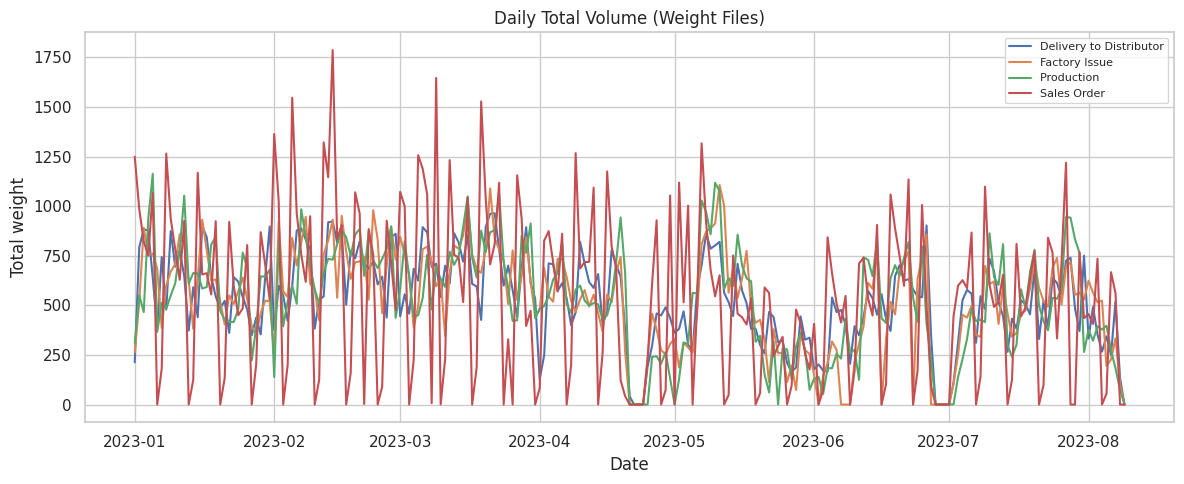

,group,file,rows,daily_total_mean,daily_total_std,zero_rate
0,unit,Delivery To distributor,221,34631.061865,14941.549912,0.357908
1,unit,Factory Issue,221,34642.360575,17341.967755,0.439355
2,unit,Production,221,34663.221719,18163.694859,0.619578
3,unit,Sales Order,221,35082.279611,28127.724430,0.461428
4,weight,Delivery to Distributor,221,530.607867,223.416451,0.357908
5,weight,Factory Issue,221,524.580469,255.224711,0.461538
6,weight,Production,221,529.470535,270.891153,0.619578
7,weight,Sales Order,221,537.781307,423.468172,0.461428


,group,file,node,total
0,unit,Delivery To distributor,SOS001L12P,1.632747e+06
1,unit,Delivery To distributor,SOS005L04P,1.498402e+06
2,unit,Delivery To distributor,SOS002L09P,1.025393e+06
3,unit,Delivery To distributor,ATN01K24P,6.363128e+05
4,unit,Delivery To distributor,SOS500M24P,6.240361e+05
...,...,...,...,...
75,weight,Sales Order,AT5X5K,4.456280e+03
76,weight,Sales Order,POV001L24P,3.871883e+03
77,weight,Sales Order,MAR01K24P,3.693312e+03
78,weight,Sales Order,ATN02K12P,3.288182e+03


In [7]:
# Parse, sort, and compute daily totals + sparsity

def prep_temporal(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    out = out.sort_values("Date").reset_index(drop=True)
    return out

for k in unit_dfs:
    unit_dfs[k] = prep_temporal(unit_dfs[k])
for k in weight_dfs:
    weight_dfs[k] = prep_temporal(weight_dfs[k])

temporal_summary = []
top_products_records = []

plt.figure(figsize=(12, 5))
for name, df in unit_dfs.items():
    numeric = df.drop(columns=["Date"]).apply(pd.to_numeric, errors="coerce")
    daily_total = numeric.sum(axis=1)
    zero_rate = float((numeric == 0).sum().sum() / numeric.size)
    plt.plot(df["Date"], daily_total, label=name)

    temporal_summary.append(
        {
            "group": "unit",
            "file": name,
            "rows": len(df),
            "daily_total_mean": float(daily_total.mean()),
            "daily_total_std": float(daily_total.std()),
            "zero_rate": zero_rate,
        }
    )

    top10 = numeric.sum().sort_values(ascending=False).head(10)
    for node, val in top10.items():
        top_products_records.append({"group": "unit", "file": name, "node": node, "total": float(val)})

plt.title("Daily Total Volume (Unit Files)")
plt.xlabel("Date")
plt.ylabel("Total units")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for name, df in weight_dfs.items():
    numeric = df.drop(columns=["Date"]).apply(pd.to_numeric, errors="coerce")
    daily_total = numeric.sum(axis=1)
    zero_rate = float((numeric == 0).sum().sum() / numeric.size)
    plt.plot(df["Date"], daily_total, label=name)

    temporal_summary.append(
        {
            "group": "weight",
            "file": name,
            "rows": len(df),
            "daily_total_mean": float(daily_total.mean()),
            "daily_total_std": float(daily_total.std()),
            "zero_rate": zero_rate,
        }
    )

    top10 = numeric.sum().sort_values(ascending=False).head(10)
    for node, val in top10.items():
        top_products_records.append({"group": "weight", "file": name, "node": node, "total": float(val)})

plt.title("Daily Total Volume (Weight Files)")
plt.xlabel("Date")
plt.ylabel("Total weight")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

temporal_stats_df = pd.DataFrame(temporal_summary).sort_values(["group", "file"]).reset_index(drop=True)
temporal_top_products = pd.DataFrame(top_products_records).sort_values(["group", "file", "total"], ascending=[True, True, False])

display(temporal_stats_df)
display(temporal_top_products.groupby(["group", "file"]).head(10).reset_index(drop=True))


## 6) Reshape to Long Format

Goal: create an analysis-friendly table.

Target schema:
- `date`
- `node`
- `metric` (`sales_order`, `production`, `factory_issue`, `delivery`)
- `unit_type` (`unit`, `weight`)
- `value`

1. Melt each temporal file from wide to long.
2. Add metric + unit_type columns.
3. Concatenate into one DataFrame (e.g., `ts_long`).
4. Validate row counts and nulls after merge.

In [8]:
def canonicalize_temporal_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")

    rename_map = {c: re.sub(r"\.\d+$", "", c) for c in out.columns if c != "Date"}
    out = out.rename(columns=rename_map)

    values = out.drop(columns=["Date"]).apply(pd.to_numeric, errors="coerce")
    values = values.T.groupby(level=0).sum().T

    out = pd.concat([out[["Date"]], values], axis=1)
    return out


def melt_temporal_dict(dfs: dict, metric_map: dict, unit_type: str) -> pd.DataFrame:
    chunks = []
    for file_key, raw in dfs.items():
        df = canonicalize_temporal_columns(raw)
        long = df.melt(id_vars="Date", var_name="node", value_name="value")
        long = long.rename(columns={"Date": "date"})
        long["metric"] = metric_map[file_key]
        long["unit_type"] = unit_type
        chunks.append(long)
    return pd.concat(chunks, ignore_index=True)


unit_long = melt_temporal_dict(unit_dfs, unit_metric_map, "unit")
weight_long = melt_temporal_dict(weight_dfs, weight_metric_map, "weight")

ts_long = pd.concat([unit_long, weight_long], ignore_index=True)
ts_long["value"] = pd.to_numeric(ts_long["value"], errors="coerce")

# Consolidate duplicate keys (can happen after column canonicalization)
ts_long = (
    ts_long.groupby(["date", "node", "metric", "unit_type"], as_index=False)["value"]
    .sum(min_count=1)
    .sort_values(["date", "node", "metric", "unit_type"])
    .reset_index(drop=True)
)

display(ts_long.head())
print(f"ts_long shape: {ts_long.shape}")
print(f"null values in ts_long['value']: {int(ts_long['value'].isna().sum())}")


,date,node,metric,unit_type,value
0,2023-01-01,AT5X5K,delivery,unit,707.000
1,2023-01-01,AT5X5K,delivery,weight,17.675
2,2023-01-01,AT5X5K,factory_issue,unit,970.000
3,2023-01-01,AT5X5K,factory_issue,weight,24.250
4,2023-01-01,AT5X5K,production,unit,1500.000


ts_long shape: (70720, 5)
null values in ts_long['value']: 0


## 7) Business-Focused Diagnostics

Goal: compute supply-chain diagnostic features.

1. Build daily node-level pivots for Unit metrics.
2. Compute:
   - `demand_gap = sales_order - delivery`
   - `supply_gap = production - sales_order`
   - `issue_pressure = factory_issue / production` (handle divide-by-zero)
3. Find nodes with largest average positive demand_gap.
4. Plot 2-3 node time series examples and interpret manually.

,node,avg_positive_demand_gap
33,SOS001L12P,5336.925199
36,SOS005L04P,4912.690860
34,SOS002L09P,3819.001842
1,ATN01K24P,2234.815139
39,SOS500M24P,2229.604578
22,POV001L24P,1557.444444
16,POP001L12P,1379.168539
25,POV500M24P,900.670455
0,AT5X5K,794.739141
35,SOS003L04P,763.122604


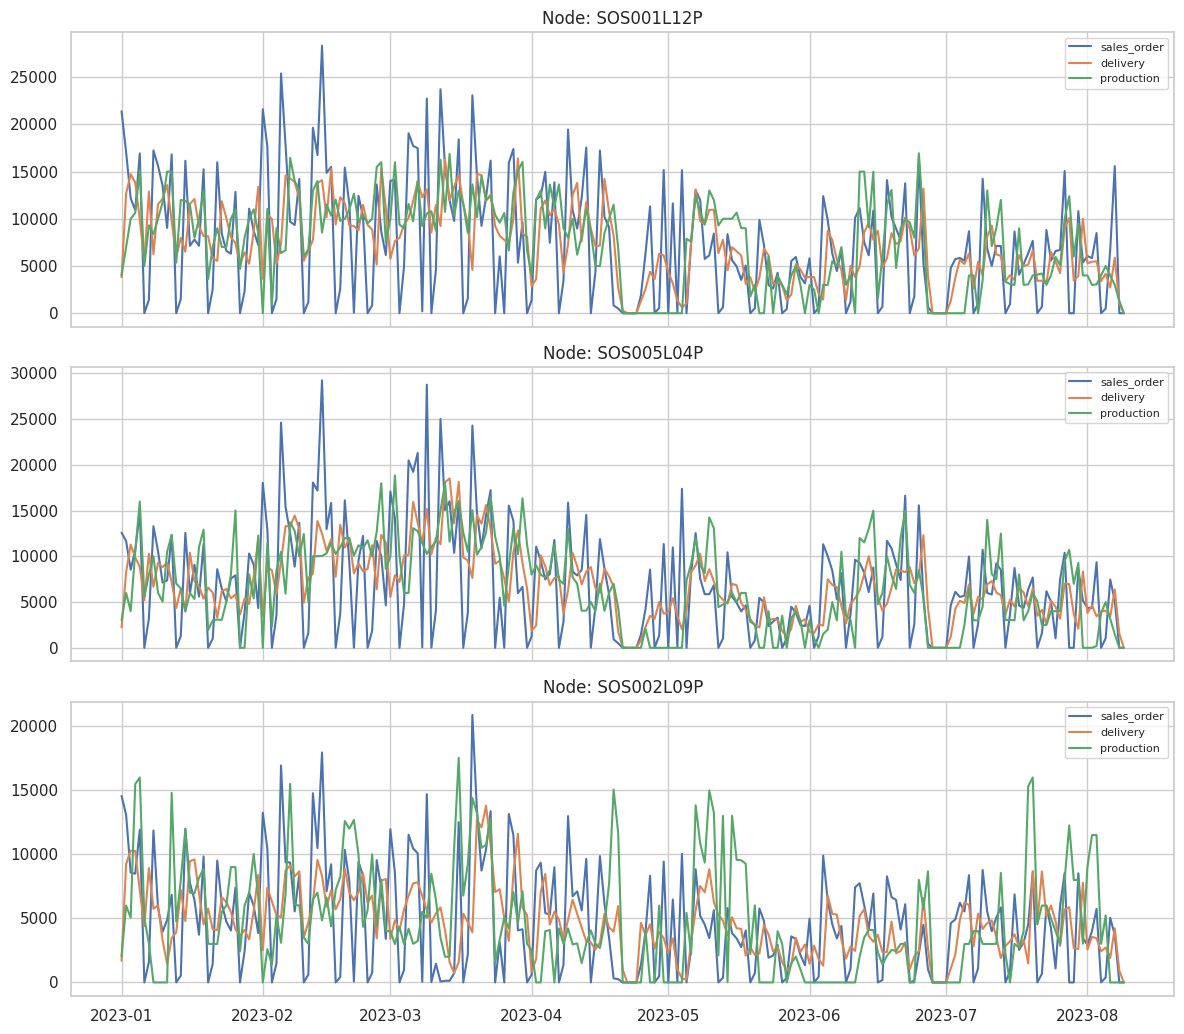

In [9]:
# Unit-only business diagnostics
unit_metrics = ["sales_order", "production", "factory_issue", "delivery"]

unit_diag = ts_long[(ts_long["unit_type"] == "unit") & (ts_long["metric"].isin(unit_metrics))].copy()

daily_node = (
    unit_diag.pivot_table(index=["date", "node"], columns="metric", values="value", aggfunc="sum")
    .reset_index()
)

for m in unit_metrics:
    if m not in daily_node.columns:
        daily_node[m] = 0.0

daily_node["demand_gap"] = daily_node["sales_order"] - daily_node["delivery"]
daily_node["supply_gap"] = daily_node["production"] - daily_node["sales_order"]
daily_node["issue_pressure"] = np.where(
    daily_node["production"] > 0,
    daily_node["factory_issue"] / daily_node["production"],
    np.nan,
)

positive_demand_gap = (
    daily_node[daily_node["demand_gap"] > 0]
    .groupby("node", as_index=False)["demand_gap"]
    .mean()
    .rename(columns={"demand_gap": "avg_positive_demand_gap"})
    .sort_values("avg_positive_demand_gap", ascending=False)
)

display(positive_demand_gap.head(15))

# Plot 3 example nodes by largest average positive demand gap
example_nodes = positive_demand_gap["node"].head(3).tolist()
if example_nodes:
    _, axes = plt.subplots(len(example_nodes), 1, figsize=(12, 3.5 * len(example_nodes)), sharex=True)
    if len(example_nodes) == 1:
        axes = [axes]

    for ax, node in zip(axes, example_nodes):
        s = daily_node[daily_node["node"] == node].sort_values("date")
        ax.plot(s["date"], s["sales_order"], label="sales_order")
        ax.plot(s["date"], s["delivery"], label="delivery")
        ax.plot(s["date"], s["production"], label="production")
        ax.set_title(f"Node: {node}")
        ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


## 8) Graph + Time Linkage

Goal: connect topology with temporal behavior.

1. Compute node degree per edge type (or combined).
2. Compute temporal volatility per node (std or coefficient of variation).
3. Merge degree + volatility and inspect correlation.
4. Write 2-3 hypotheses (not conclusions yet).

,node,degree,weighted_degree,mean_value,std_value,cv
0,AT5X5K,39,348,800.978891,784.581838,0.979529
15,MASR025K,39,197,91.961538,126.341538,1.373852
38,SOS250M48P,39,289,219.500967,456.319832,2.078897
37,SOS008L02P,39,391,385.339834,530.497586,1.376701
36,SOS005L04P,39,451,6763.817081,4845.967360,0.716455
35,SOS003L04P,39,451,1002.999489,946.652106,0.943821
34,SOS002L09P,39,451,4753.979387,3807.906901,0.800994
33,SOS001L12P,39,451,7457.478026,5038.397399,0.675617
27,SE500G24P,39,356,681.924166,562.699253,0.825164
23,POV002L09P,39,445,551.694321,577.871320,1.047448


Correlation matrix:


,degree,weighted_degree,std_value,cv
degree,1.000000,0.880812,0.479725,-0.749564
weighted_degree,0.880812,1.000000,0.595624,-0.728121
std_value,0.479725,0.595624,1.000000,-0.363308
cv,-0.749564,-0.728121,-0.363308,1.000000


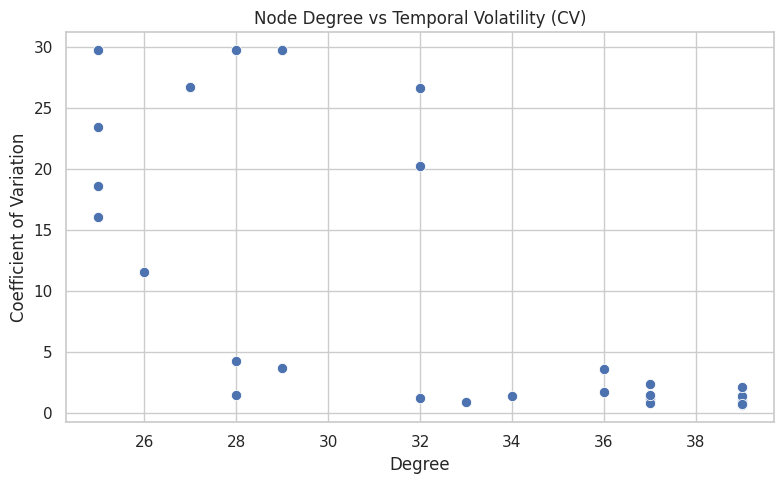

Hypothesis prompts:
1. High-degree nodes may carry more variable demand due to central routing roles.
2. Nodes with high weighted-degree but low CV might be stable backbone products.
3. Outliers with low degree and high CV may indicate specialized or sporadic flows.


In [10]:
# Degree vs volatility linkage
if "G_weighted" not in globals():
    raise RuntimeError("Run Section 4 first to build G_weighted.")

if "ts_long" not in globals():
    raise RuntimeError("Run Section 6 first to build ts_long.")

degree_df = pd.DataFrame(
    {
        "node": list(dict(G_weighted.degree()).keys()),
        "degree": list(dict(G_weighted.degree()).values()),
        "weighted_degree": list(dict(G_weighted.degree(weight="weight")).values()),
    }
)

unit_ts = ts_long[ts_long["unit_type"] == "unit"].copy()
volatility_df = (
    unit_ts.groupby("node", as_index=False)["value"]
    .agg(mean_value="mean", std_value="std")
    .assign(cv=lambda d: d["std_value"] / d["mean_value"].replace(0, np.nan))
)

degree_volatility = degree_df.merge(volatility_df, on="node", how="left")

a = degree_volatility[["degree", "weighted_degree", "std_value", "cv"]].corr(numeric_only=True)
display(degree_volatility.sort_values("degree", ascending=False).head(20))
print("Correlation matrix:")
display(a)

plt.figure(figsize=(8, 5))
plot_df = degree_volatility.dropna(subset=["degree", "cv"])
sns.scatterplot(data=plot_df, x="degree", y="cv", s=55)
plt.title("Node Degree vs Temporal Volatility (CV)")
plt.xlabel("Degree")
plt.ylabel("Coefficient of Variation")
plt.tight_layout()
plt.show()

print("Hypothesis prompts:")
print("1. High-degree nodes may carry more variable demand due to central routing roles.")
print("2. Nodes with high weighted-degree but low CV might be stable backbone products.")
print("3. Outliers with low degree and high CV may indicate specialized or sporadic flows.")


## Export Cleaned Tables

Save exported CSVs to `DataExploration/Processed/`.

In [11]:
# Create output folder for Neo4j/GraphRAG-ready tables
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Build products table: code, group, subgroup
products = pd.DataFrame()
if "Nodes" in nodes_dfs and "Node" in nodes_dfs["Nodes"].columns:
    products = nodes_dfs["Nodes"][["Node"]].copy().rename(columns={"Node": "code"})
else:
    node_candidates = [df for df in nodes_dfs.values() if "Node" in df.columns]
    if not node_candidates:
        raise ValueError("No node table with a 'Node' column was found in nodes_dfs.")
    first_nodes_df = node_candidates[0]
    products = first_nodes_df[["Node"]].copy().rename(columns={"Node": "code"})

pg_df = next(
    (
        df
        for df in nodes_dfs.values()
        if {"Node", "Group", "Sub-Group"}.issubset(df.columns)
    ),
    None,
)
if pg_df is not None:
    pg_map = (
        pg_df[["Node", "Group", "Sub-Group"]]
        .copy()
        .rename(columns={"Node": "code", "Group": "group", "Sub-Group": "subgroup"})
        .drop_duplicates(subset=["code"])
    )
    products = products.merge(pg_map, on="code", how="left")
else:
    products["group"] = pd.NA
    products["subgroup"] = pd.NA

products["code"] = products["code"].astype(str)
products = products.drop_duplicates(subset=["code"]).sort_values("code").reset_index(drop=True)
products.to_csv(PROCESSED_DIR / "products.csv", index=False)

# Build product-plant and product-storage link tables
ps_df = next(
    (
        df
        for df in nodes_dfs.values()
        if {"Node", "Plant", "Storage Location"}.issubset(df.columns)
    ),
    None,
)

if ps_df is not None:
    links = ps_df[["Node", "Plant", "Storage Location"]].copy().rename(columns={"Node": "product_code"})
    links["product_code"] = links["product_code"].astype(str)

    plant_links = links[["product_code", "Plant"]].rename(columns={"Plant": "plant_id"}).copy()
    plant_links["plant_id"] = pd.to_numeric(plant_links["plant_id"], errors="coerce")
    plant_links = plant_links.dropna(subset=["plant_id"])
    plant_links["plant_id"] = plant_links["plant_id"].astype(int).astype(str)
    plant_links = plant_links.drop_duplicates().sort_values(["product_code", "plant_id"]).reset_index(drop=True)
    plant_links.to_csv(PROCESSED_DIR / "product_plant.csv", index=False)

    storage_links = links[["product_code", "Storage Location"]].rename(columns={"Storage Location": "storage_id"}).copy()
    storage_links["storage_id"] = pd.to_numeric(storage_links["storage_id"], errors="coerce")
    storage_links = storage_links.dropna(subset=["storage_id"])
    storage_links["storage_id"] = storage_links["storage_id"].astype(int).astype(str)
    storage_links = storage_links.drop_duplicates().sort_values(["product_code", "storage_id"]).reset_index(drop=True)
    storage_links.to_csv(PROCESSED_DIR / "product_storage.csv", index=False)
else:
    pd.DataFrame(columns=["product_code", "plant_id"]).to_csv(PROCESSED_DIR / "product_plant.csv", index=False)
    pd.DataFrame(columns=["product_code", "storage_id"]).to_csv(PROCESSED_DIR / "product_storage.csv", index=False)

# Build temporal observations table from ts_long
if "ts_long" in globals():
    obs = ts_long.copy().rename(columns={"node": "product_code"})
    obs["product_code"] = obs["product_code"].astype(str)
    obs["date"] = pd.to_datetime(obs["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    obs["metric"] = obs["metric"].astype(str)
    obs["unit_type"] = obs["unit_type"].astype(str)
    obs["value"] = pd.to_numeric(obs["value"], errors="coerce")

    obs = obs.dropna(subset=["product_code", "date", "metric", "unit_type"])
    obs["obs_key"] = (
        obs["product_code"]
        + "|"
        + obs["date"]
        + "|"
        + obs["metric"]
        + "|"
        + obs["unit_type"]
    )
    obs = obs[["obs_key", "product_code", "date", "metric", "unit_type", "value"]]
    obs = obs.drop_duplicates(subset=["obs_key"]).sort_values("obs_key").reset_index(drop=True)
    obs.to_csv(PROCESSED_DIR / "observations.csv", index=False)

print(f"Exports configured. CSVs will be written to: {PROCESSED_DIR.resolve()}")


Exports configured. CSVs will be written to: /mnt/c/Users/UM6P/Desktop/Learning/S4 - CI/GenAI/FinalProject/DataExploration/Processed
